# Deteção de trojans em fluxos de rede

Notebook da componente de Márcio Araújo. Carrega os resultados reproduzidos, todos os classificadores e os dois agentes locais. O critério original de produção não foi atingido.

In [1]:
from pathlib import Path
import os, sys, json
ROOT=Path.cwd()
if not (ROOT / "src").exists(): ROOT=ROOT.parent
os.chdir(ROOT)
sys.path.insert(0,str(ROOT))
import pandas as pd
from IPython.display import display, Markdown, Image
from src.preparacao import carregar
from src.modelacao import treinar
from src.eda import analisar
from src.inferencia import Predictor
ROOT

WindowsPath('D:/Transferencias/projeto-trojan-detection/projeto')

## Dados e qualidade

A EDA é descritiva. Não usamos o teste para ajustar preparação, escolher candidatos ou selecionar limiar.

,Valor
linhas,177482
colunas,86
classes,"{'Trojan': 90683, 'Benign': 86799}"
valores_em_falta,0
valores_infinitos,0
duplicados_sem_indice,0
colunas_constantes,"[Bwd PSH Flags, Fwd URG Flags, Bwd URG Flags, ..."
grupos_assinatura_com_rotulos_distintos,0
linhas_nesses_grupos,0
definicao_assinatura,"Todas as colunas exceto Class, Timestamp e índ..."


,dia,Benign,Trojan
0,2017-06-30,6607,0
1,2017-07-02,27309,0
2,2017-07-04,11977,735
3,2017-07-05,40902,562
4,2017-07-06,4,0
5,2017-07-10,0,1886
6,2017-07-11,0,42983
7,2017-07-13,0,4648
8,2017-07-14,0,24093
9,2017-07-17,0,15776


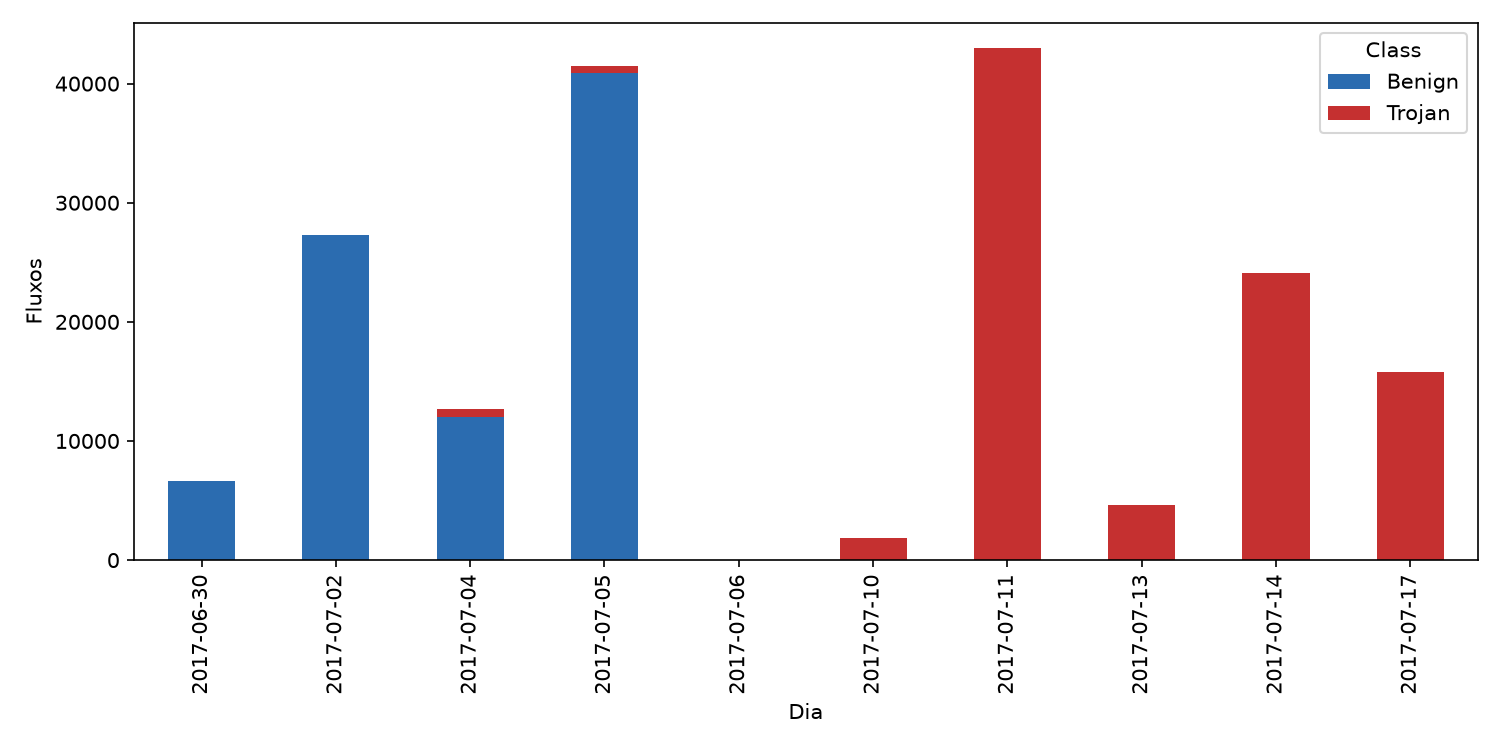

In [2]:
quality=json.loads((ROOT/"reports/qualidade_dados.json").read_text(encoding="utf-8"))
display(pd.Series(quality).to_frame("Valor"))
display(pd.read_csv(ROOT/"reports/eda_distribuicao_por_dia.csv"))
display(Image(filename=str(ROOT/"figs/distribuicao_por_dia.png")))

## Reproduzir a experiência

O retreino é explícito porque a execução demora alguns minutos e o teste já foi observado. Para nova seleção de melhorias, definir primeiro outra reserva de teste.

In [3]:
RETREINAR=False
if RETREINAR:
    analisar(ROOT/"data/Trojan_Detection.csv")
    treinar(ROOT/"data/Trojan_Detection.csv")
display(pd.read_csv(ROOT/"reports/comparacao_validacao.csv"))
assessment=json.loads((ROOT/"reports/avaliacao_final.json").read_text(encoding="utf-8"))
display(pd.Series(assessment["teste"]).to_frame("Teste reservado"))
print("Critério atingido:",assessment["criterio_original"]["atingido_no_teste"])

,n,trojan,limiar,auc_roc,auc_pr,exatidao,recall,precisao,f1,fpr,tn,fp,fn,tp,brier,alertas,modelo,conjunto,tempo_treino_s
0,111185,40172,0.788147,0.500000,0.361308,0.638692,0.000000,0.000000,0.000000,0.000000,71013,0,40172,0,0.412956,0,trivial,validacao_grupos,0.763895
1,111185,40172,0.915801,0.532344,0.416754,0.640950,0.094618,0.517073,0.159965,0.049991,67463,3550,36371,3801,0.453938,7351,logistica,validacao_grupos,1.185191
2,111185,40172,0.960784,0.570981,0.431770,0.643288,0.100244,0.533872,0.168794,0.049512,67497,3516,36145,4027,0.433572,7543,arvore,validacao_grupos,1.838581
3,111185,40172,0.930335,0.583480,0.450370,0.648766,0.116250,0.568127,0.193007,0.049991,67463,3550,35502,4670,0.413632,8220,rf,validacao_grupos,4.845373
4,111185,40172,0.927568,0.592427,0.471768,0.651230,0.123071,0.582058,0.203181,0.049991,67463,3550,35228,4944,0.416815,8494,hgb,validacao_grupos,1.760964
5,111185,40172,0.911190,0.567211,0.441578,0.646472,0.109902,0.554300,0.183435,0.049991,67463,3550,35757,4415,0.430092,7965,hgb_regularizado,validacao_grupos,1.985375
6,111185,40172,0.925481,0.577590,0.451375,0.647983,0.114084,0.563507,0.189753,0.049991,67463,3550,35589,4583,0.409597,8133,hgb_sem_portas_host,validacao_grupos,4.125919


,Teste reservado
n,5604.000000
trojan,2676.000000
limiar,0.927568
auc_roc,0.642496
auc_pr,0.546443
exatidao,0.520878
recall,0.042975
precisao,0.481172
f1,0.078902
fpr,0.042350


Critério atingido: False


## Carregar todos os classificadores

O mesmo CSV sem Class é pontuado por todos os pipelines serializados; a tabela seguinte é uma demonstração de inferência e não uma nova seleção de modelo.

In [4]:
import joblib
from threadpoolctl import threadpool_limits
sample=carregar(ROOT/"examples/fluxos_sem_rotulo.csv")
scores={}
with threadpool_limits(limits=4):
    for path in sorted((ROOT/"models").glob("*.joblib")):
        bundle=joblib.load(path)
        scores[path.stem]=bundle["pipeline"].predict_proba(sample)[:,1]
display(pd.DataFrame(scores))
display(Predictor().predict(sample))

,arvore,hgb,hgb_regularizado,hgb_sem_portas_host,logistica,modelo_trojan,rf,trivial
0,0.966667,0.933073,0.909657,0.900124,0.934696,0.933073,0.844383,0.788147
1,0.871795,0.719820,0.604844,0.846205,0.647209,0.719820,0.931688,0.788147
2,0.229342,0.200245,0.275565,0.257387,0.457413,0.200245,0.170913,0.788147
3,0.352941,0.740124,0.720357,0.785113,0.619721,0.740124,0.770030,0.788147
4,0.218750,0.562630,0.607684,0.772163,0.557358,0.562630,0.359770,0.788147


,score_trojan,alerta,acao
0,0.933073,True,revisao_manual
1,0.719820,False,sem_alerta
2,0.200245,False,sem_alerta
3,0.740124,False,sem_alerta
4,0.562630,False,sem_alerta


## Contrato da API

Testamos a API local com as mesmas funções da CLI, sem necessidade de iniciar um servidor separado.

In [5]:
from fastapi.testclient import TestClient
from api import app
request=json.loads((ROOT/"examples/pedido_api.json").read_text(encoding="utf-8"))
with TestClient(app) as client:
    display(client.get("/health").json())
    response=client.post("/predict",json=request)
    response.raise_for_status()
    display(pd.DataFrame(response.json()["predictions"]))

{'status': 'ok',
 'model': 'hgb',
 'deployment_approved': False,
 'mode': 'demonstracao_local'}

,score_trojan,alerta,acao
0,0.933073,True,revisao_manual
1,0.719820,False,sem_alerta


## Agentes em Python e LangGraph

Os pesos Qwen locais são pré-treinados pelos autores. O classificador calcula os factos e o gerador produz um comentário auxiliar, que exige revisão. Ambas as versões são chamadas abaixo. Se os pesos não estiverem instalados, a geração neural é explicitamente desativada e isso aparece na saída.

In [6]:
from src.agentes import executar
USAR_LLM=(ROOT/"models/llm/config.json").exists()
print("Geração neural local ativa:",USAR_LLM)
results={}
for backend in ["python","langgraph"]:
    try:
        results[backend]=executar(backend=backend,usar_llm=USAR_LLM,guardar=False)
        display(Markdown("### "+backend))
        display(pd.Series(results[backend]["fatos"]).to_frame("Factos calculados"))
        display(Markdown(results[backend]["texto"]))
    except ModuleNotFoundError as exc:
        print("Dependência opcional em falta:",exc)
if len(results)==2: assert results["python"]["fatos"]==results["langgraph"]["fatos"]

Geração neural local ativa: True


D:\Transferencias\projeto-trojan-detection\projeto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### python

,Factos calculados
fluxos,5
alertas,1
modelo,hgb
limiar,0.927568
criterio_deployment_atingido,False
recall_teste,0.042975
fpr_teste,0.04235
acao,"Revisão manual, sem bloqueio automático."


Comentário neural rejeitado pelo controlo de conteúdo. Consulte os factos calculados.

O modelo não está aprovado para produção.

### langgraph

,Factos calculados
fluxos,5
alertas,1
modelo,hgb
limiar,0.927568
criterio_deployment_atingido,False
recall_teste,0.042975
fpr_teste,0.04235
acao,"Revisão manual, sem bloqueio automático."


Comentário neural rejeitado pelo controlo de conteúdo. Consulte os factos calculados.

O modelo não está aprovado para produção.

## Interpretação e entrega

Os IPs dominantes, o contexto temporal e a antiguidade dos dados limitam a generalização. O modelo não está aprovado para produção. Consultar docs/guia_tecnico.md, docs/diagramas.md e docs/estado_final.md. O relatório académico e a apresentação são elaborados pelos alunos.